<a href="https://colab.research.google.com/github/CheddaniAmel/cryptosoundpython/blob/main/cryptosound.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install pydub
!apt-get install ffmpeg


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [9]:
from google.colab import files
uploaded = files.upload()  # Choisis ton fichier .wav


Saving test.mp3 to test.mp3


In [10]:
from pydub import AudioSegment

filename_mp3 = list(uploaded.keys())[0]
audio = AudioSegment.from_mp3(filename_mp3)
filename_wav = filename_mp3.replace('.mp3', '.wav')
audio.export(filename_wav, format="wav")


<_io.BufferedRandom name='test.wav'>

In [16]:
!pip install git+https://github.com/openai/whisper.git
!sudo apt update && sudo apt install ffmpeg


  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-ru6jjzza
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-ru6jjzza
  Resolved https://github.com/openai/whisper.git to commit 517a43ecd132a2089d85f4ebc044728a71d49f6e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 843.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━

In [18]:
import whisper

# Charger le modèle
model = whisper.load_model("base")  # Tu peux aussi tester "small", "medium", "large"

# Transcrire le fichier (remplace par ton fichier)
result = model.transcribe("test.wav")  # attention : fichier .wav requis ici
print("🗣️ Transcription originale :")
print(result["text"])


/usr/local/lib/python3.11/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


🗣️ Transcription originale :
 Bonjour à tous, je m'appelle Amel, je suis étudiant en informatique.


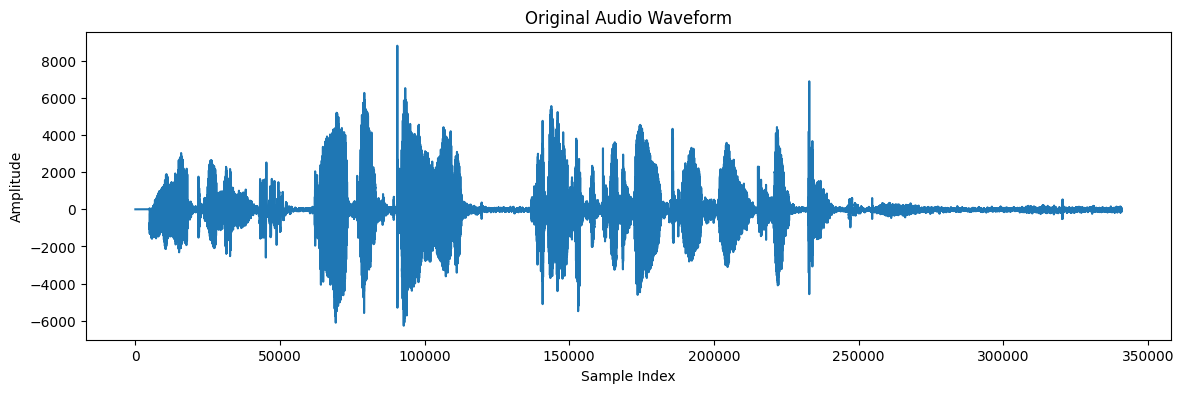

In [19]:
from scipy.io import wavfile
import matplotlib.pyplot as plt

sample_rate, data = wavfile.read(filename_wav)
if data.ndim > 1:
    data = data[:, 0]  # Ne prendre qu'un canal si stéréo

plt.figure(figsize=(14, 4))
plt.plot(data)
plt.title("Original Audio Waveform")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()


In [13]:
!pip install pycryptodome


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 24.0 MB/s eta 0:00:00


In [14]:
from Crypto.Cipher import AES, PKCS1_OAEP
from Crypto.PublicKey import RSA
from Crypto.Random import get_random_bytes

# Générer une clé RSA
key = RSA.generate(2048)
private_key = key
public_key = key.publickey()

# Générer une clé AES
aes_key = get_random_bytes(16)

# Chiffrer les données audio avec AES
cipher_aes = AES.new(aes_key, AES.MODE_EAX)
ciphertext, tag = cipher_aes.encrypt_and_digest(data.tobytes())

# Chiffrer la clé AES avec RSA
cipher_rsa = PKCS1_OAEP.new(public_key)
enc_aes_key = cipher_rsa.encrypt(aes_key)


In [21]:
enc_aes_key = cipher_rsa.encrypt(aes_key)


In [22]:
import base64

# Représenter le texte chiffré sous forme base64 (lisible)
ciphertext_b64 = base64.b64encode(ciphertext).decode('utf-8')

print("🔐 Texte audio chiffré (Base64) :")
print(ciphertext_b64[:500] + " ...")  # Affiche les 500 premiers caractères seulement


🔐 Texte audio chiffré (Base64) :
jWx3KXGovSwrc1U6gsJBg1KtJVRJk5C/VzP2vM2i/uPGSzAXCDdsir/awXKjKQWQHz/quCuIENg0Q5nu4El9fkArp33zwT+Jmefq7LVmAK9I70dIiBHKIcfr0y43xCH78GfCPJuYccUbFBlRb94bGEJe3yWfYqKUTipFbjc56VH9xB5i/I7fbYCQehIU8GNsEwfVpqxFJk/LnYWwQEwXSCkotIidyIjYDNBIrNFgeN/JdI1SSmySnTrgKJdiXj2HQY0Yw1U9a8tEZvdqurDbsOyEv9LMLVw9dEjBJTmoGiZBTXdRLTRRfWWzZ/tADD9AsWkTyD91KvGjhKj8B0lCMipuh2zcXFAtUAJiefOz/ehRyJDXGIxqbgKvtV8Uz2X/P2/66co+cm+mZRATtbGhuJM0wNmvV3dyHNgGqnGT1wWObBPKlE8tYKKEq+TaYnJvyYokWd7hOn5bQ3OUuBIMSTrUZ/XMoRgU8150NDAh7Ifmzufer5R+ ...


In [ ]:
# Convertir les données chiffrées en tableau de "pseudo-amplitudes"
ciphered_array = np.frombuffer(ciphertext[:len(data)*2], dtype=np.int16)

# Afficher le graphe du signal chiffré
plt.figure(figsize=(12, 4))
plt.plot(ciphered_array, color='red')
plt.title("🔐 Signal Audio Chiffré (simulé)")
plt.xlabel("Échantillons")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128272 (\N{CLOSED LOCK WITH KEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


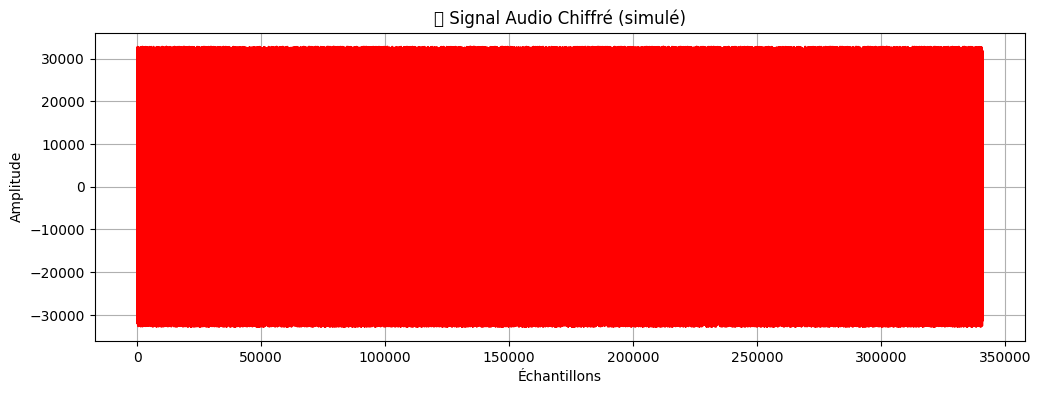

In [20]:
# Convertir les données chiffrées en tableau de "pseudo-amplitudes"
ciphered_array = np.frombuffer(ciphertext[:len(data)*2], dtype=np.int16)

# Afficher le graphe du signal chiffré
plt.figure(figsize=(12, 4))
plt.plot(ciphered_array, color='red')
plt.title("🔐 Signal Audio Chiffré (simulé)")
plt.xlabel("Échantillons")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


In [23]:
# Déchiffrement de la clé AES
decipher_rsa = PKCS1_OAEP.new(private_key)
decrypted_aes_key = decipher_rsa.decrypt(enc_aes_key)

# Déchiffrement du son
cipher_aes_dec = AES.new(decrypted_aes_key, AES.MODE_EAX, nonce=cipher_aes.nonce)
decrypted_data = cipher_aes_dec.decrypt(ciphertext)

# Conversion en numpy
decrypted_audio = np.frombuffer(decrypted_data, dtype=np.int16)


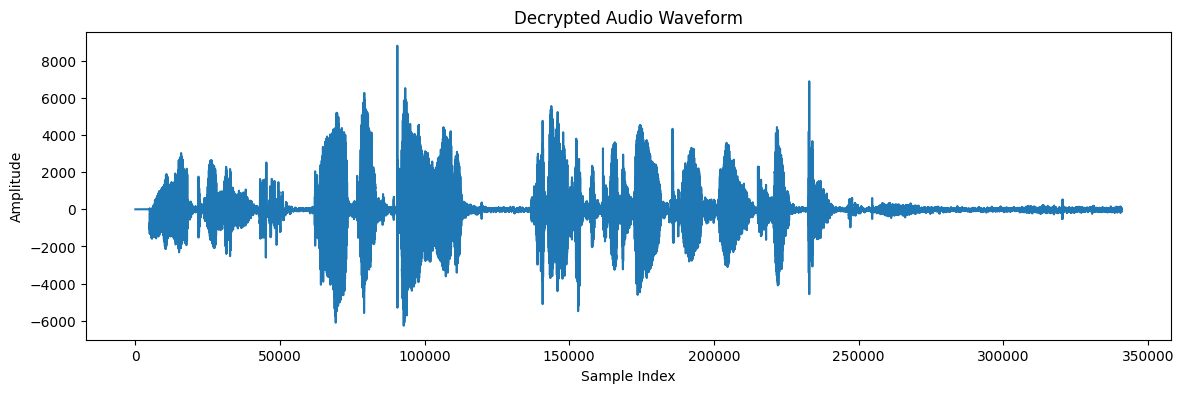

In [24]:
plt.figure(figsize=(14, 4))
plt.plot(decrypted_audio)
plt.title("Decrypted Audio Waveform")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()


In [25]:
from IPython.display import Audio

Audio(decrypted_audio, rate=sample_rate)
